# PHẦN 1: KHÁM PHÁ DỮ LIỆU (EXPLORATORY DATA ANALYSIS - EDA)
**Nội dung thực hiện bám sát yêu cầu đề bài:**
1. **Tóm tắt thông tin dữ liệu**: Số lượng bản ghi, biến số, kiểu dữ liệu, kiểm tra & xử lý missing, duplicates.
2. **Phân tích thống kê mô tả**: Tính toán Mean, Median, Std, Tứ phân vị; Trực quan hóa ít nhất 3 loại biểu đồ có giải thích lý do lựa chọn.
3. **Phát hiện & xử lý dữ liệu ngoại lai (Outliers)**: Trình bày phương pháp (IQR, Z-score) và đề xuất hướng xử lý.
4. **Nhận xét tổng quan về tập dữ liệu**: Rút ra các đặc điểm nổi bật phục vụ các bước phân tích tiếp theo.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cấu hình hiển thị số liệu và đồ thị
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print("Đã tải thành công các thư viện!")

Đã tải thành công các thư viện!


## 1. Tóm tắt thông tin dữ liệu

In [29]:
import os
import pandas as pd

# 1. Đọc dữ liệu từ thư mục data
input_path = 'data/insurance.csv'
df_raw = pd.read_csv(input_path)
print(f"[1] KÍCH THƯỚC DỮ LIỆU BAN ĐẦU: {df_raw.shape[0]} dòng (records), {df_raw.shape[1]} cột (features)")

# 2. Kiểm tra kiểu dữ liệu & cấu trúc tổng quan
print("\n" + "="*60)
print("[2] THÔNG TIN CẤU TRÚC VÀ KIỂU DỮ LIỆU CỦA TỪNG BIẾN:")
print("="*60)
df_raw.info()

# 3. Kiểm tra dữ liệu khuyết thiếu (Missing Values)
print("\n" + "="*60)
print("[3] KIỂM TRA DỮ LIỆU KHUYẾT THIẾU:")
print("="*60)
missing_df = pd.DataFrame({
    'Kiểu dữ liệu': df_raw.dtypes,
    'Số lượng khuyết': df_raw.isnull().sum(),
    'Tỷ lệ khuyết (%)': (df_raw.isnull().sum() / len(df_raw)) * 100
})
display(missing_df)

# 4a. Kiểm tra và xử lý dữ liệu trùng lặp (Duplicates)
print("="*60)
print("[4a] KIỂM TRA & XỬ LÝ DỮ LIỆU TRÙNG LẶP:")
print("="*60)
n_duplicates = df_raw.duplicated().sum()
print(f"* Số lượng bản ghi trùng lặp hoàn toàn: {n_duplicates}")

if n_duplicates > 0:
    print("\nChi tiết bản ghi trùng lặp:")
    display(df_raw[df_raw.duplicated(keep=False)])
    
    # Loại bỏ bản ghi trùng lặp, giữ lại bản ghi đầu tiên
    df = df_raw.drop_duplicates(keep='first').copy()
    print(f"\n-> ĐÃ LOẠI BỎ {n_duplicates} DÒNG TRÙNG LẶP!")
else:
    df = df_raw.copy()

print(f"* KÍCH THƯỚC DỮ LIỆU SAU LÀM SẠCH: {df.shape[0]} dòng, {df.shape[1]} cột")

# 4b. KIỂM TRA TÍNH NHẤT QUÁN CỦA BIẾN PHÂN LOẠI (CATEGORICAL INTEGRITY)
expected_values = {
    'sex': {'male', 'female'},
    'smoker': {'yes', 'no'},
    'region': {'northeast', 'northwest', 'southeast', 'southwest'}
}

cat_check = []
for col, expected in expected_values.items():
    df[col] = df[col].astype(str).str.strip().str.lower()
    actual = set(df[col].unique())
    invalid = actual - expected
    cat_check.append({
        'Biến phân loại': col,
        'Giá trị thực tế trong data': str(sorted(actual)),
        'Số giá trị sai lệch': len(invalid),
        'Trạng thái': 'Hợp lệ' if len(invalid) == 0 else f'Lỗi: {invalid}'
    })

print("--- \nKIỂM TRA TÍNH NHẤT QUÁN BIẾN ĐỊNH TÍNH ---")
display(pd.DataFrame(cat_check))

# 4c. KIỂM TRA MIỀN GIÁ TRỊ HỢP LÝ CỦA BIẾN SỐ 
valid_ranges = {
    'age': (18, 64),
    'bmi': (10, 60),
    'children': (0, 10),
    'charges': (0, np.inf)
}

num_check = []
for col, (lo, hi) in valid_ranges.items():
    n_invalid = ((df[col] < lo) | (df[col] > hi)).sum()
    num_check.append({
        'Biến số': col,
        'Min': round(df[col].min(), 2),
        'Max': round(df[col].max(), 2),
        'Khoảng hợp lệ kỳ vọng': f"[{lo}, {hi if hi != np.inf else '+inf'}]",
        'Số bản ghi vi phạm': n_invalid,
        'Trạng thái': 'Hợp lệ' if n_invalid == 0 else f'{n_invalid} lỗi'
    })

print("\n--- KIỂM TRA MIỀN GIÁ TRỊ BIẾN ĐỊNH LƯỢNG ---")
display(pd.DataFrame(num_check))

# 5. Lưu tập dữ liệu đã làm sạch ra file clean_data.csv
output_dir = 'data'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'clean_data.csv')
df.to_csv(output_path, index=False)
print(f"\n-> ĐÃ XUẤT THÀNH CÔNG FILE SẠCH TẠI: '{output_path}'")

# 6. Hiển thị mẫu 5 dòng đầu tiên sau tiền xử lý
print("\n" + "="*60)
print("[6] MẪU 5 DÒNG ĐẦU TIÊN CỦA TẬP DỮ LIỆU SAU TIỀN XỬ LÝ:")
print("="*60)
display(df.head())

[1] KÍCH THƯỚC DỮ LIỆU BAN ĐẦU: 1338 dòng (records), 7 cột (features)

[2] THÔNG TIN CẤU TRÚC VÀ KIỂU DỮ LIỆU CỦA TỪNG BIẾN:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

[3] KIỂM TRA DỮ LIỆU KHUYẾT THIẾU:


,Kiểu dữ liệu,Số lượng khuyết,Tỷ lệ khuyết (%)
age,int64,0,0.0000
sex,object,0,0.0000
bmi,float64,0,0.0000
children,int64,0,0.0000
smoker,object,0,0.0000
region,object,0,0.0000
charges,float64,0,0.0000


[4a] KIỂM TRA & XỬ LÝ DỮ LIỆU TRÙNG LẶP:
* Số lượng bản ghi trùng lặp hoàn toàn: 1

Chi tiết bản ghi trùng lặp:


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.5900,0,no,northwest,1639.5631
581,19,male,30.5900,0,no,northwest,1639.5631



-> ĐÃ LOẠI BỎ 1 DÒNG TRÙNG LẶP!
* KÍCH THƯỚC DỮ LIỆU SAU LÀM SẠCH: 1337 dòng, 7 cột
--- 
KIỂM TRA TÍNH NHẤT QUÁN BIẾN ĐỊNH TÍNH ---


,Biến phân loại,Giá trị thực tế trong data,Số giá trị sai lệch,Trạng thái
0,sex,"['female', 'male']",0,Hợp lệ
1,smoker,"['no', 'yes']",0,Hợp lệ
2,region,"['northeast', 'northwest', 'southeast', 'south...",0,Hợp lệ



--- KIỂM TRA MIỀN GIÁ TRỊ BIẾN ĐỊNH LƯỢNG ---


,Biến số,Min,Max,Khoảng hợp lệ kỳ vọng,Số bản ghi vi phạm,Trạng thái
0,age,18.0000,64.0000,"[18, 64]",0,Hợp lệ
1,bmi,15.9600,53.1300,"[10, 60]",0,Hợp lệ
2,children,0.0000,5.0000,"[0, 10]",0,Hợp lệ
3,charges,1121.8700,63770.4300,"[0, +inf]",0,Hợp lệ



-> ĐÃ XUẤT THÀNH CÔNG FILE SẠCH TẠI: 'data\clean_data.csv'

[6] MẪU 5 DÒNG ĐẦU TIÊN CỦA TẬP DỮ LIỆU SAU TIỀN XỬ LÝ:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9000,0,yes,southwest,16884.9240
1,18,male,33.7700,1,no,southeast,1725.5523
2,28,male,33.0000,3,no,southeast,4449.4620
3,33,male,22.7050,0,no,northwest,21984.4706
4,32,male,28.8800,0,no,northwest,3866.8552


## 2. Phân tích thống kê mô tả

### 2.1 Tính các thống kê

In [20]:
# 1. Thống kê mô tả cho các biến định lượng 
num_cols = ['age', 'bmi', 'children', 'charges']
desc_numeric = df[num_cols].describe().T

# Bổ sung Trung vị, khoảng tứ phân vị (IQR) và độ xiên (Skewness)
desc_numeric['median'] = df[num_cols].median()
desc_numeric['IQR'] = desc_numeric['75%'] - desc_numeric['25%']
desc_numeric['skewness'] = df[num_cols].skew()

# Sắp xếp và đổi tên các cột chỉ số
stat_table = desc_numeric[['count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max', 'IQR', 'skewness']]
stat_table.columns = ['Số lượng', 'Trung bình (Mean)', 'Độ lệch chuẩn (Std)', 'Min', 'Q1 (25%)', 'Trung vị (Median)', 'Q3 (75%)', 'Max', 'IQR', 'Độ xiên (Skew)']

print("--- BẢNG TỔNG HỢP THỐNG KÊ MÔ TẢ CÁC BIẾN ĐỊNH LƯỢNG ---")
display(stat_table)

# 2. Thống kê tần số cho các biến định tính (Gom vào 01 bảng duy nhất)
cat_cols = ['sex', 'smoker', 'region']

cat_summary_list = []
for col in cat_cols:
    counts = df[col].value_counts()
    pcts = df[col].value_counts(normalize=True) * 100
    temp_df = pd.DataFrame({
        'Biến số': col,
        'Nhóm / Giá trị': counts.index,
        'Tần số': counts.values,
        'Tỷ lệ (%)': pcts.values
    })
    cat_summary_list.append(temp_df)

# Nối các bảng thành 1 bảng tổng hợp
cat_summary_table = pd.concat(cat_summary_list, ignore_index=True)

print("\n--- BẢNG TỔNG HỢP PHÂN BỐ TẦN SỐ CÁC BIẾN ĐỊNH TÍNH ---")
display(cat_summary_table)

--- BẢNG TỔNG HỢP THỐNG KÊ MÔ TẢ CÁC BIẾN ĐỊNH LƯỢNG ---


,Số lượng,Trung bình (Mean),Độ lệch chuẩn (Std),Min,Q1 (25%),Trung vị (Median),Q3 (75%),Max,IQR,Độ xiên (Skew)
age,1337.0000,39.2221,14.0443,18.0000,27.0000,39.0000,51.0000,64.0000,24.0000,0.0548
bmi,1337.0000,30.6635,6.1005,15.9600,26.2900,30.4000,34.7000,53.1300,8.4100,0.2839
children,1337.0000,1.0957,1.2056,0.0000,0.0000,1.0000,2.0000,5.0000,2.0000,0.9374
charges,1337.0000,13279.1215,12110.3597,1121.8739,4746.3440,9386.1613,16657.7175,63770.4280,11911.3734,1.5154



--- BẢNG TỔNG HỢP PHÂN BỐ TẦN SỐ CÁC BIẾN ĐỊNH TÍNH ---


,Biến số,Nhóm / Giá trị,Tần số,Tỷ lệ (%)
0,sex,male,675,50.4862
1,sex,female,662,49.5138
2,smoker,no,1063,79.5064
3,smoker,yes,274,20.4936
4,region,southeast,364,27.2251
5,region,southwest,325,24.3082
6,region,northwest,324,24.2334
7,region,northeast,324,24.2334


### 2.2 Trực quan hóa dữ liệu nhận diện xu hướng (Áp dụng 4 loại biểu đồ)
1. **Biểu đồ 1: Histogram kết hợp KDE (Density Plot):**
   - *Lý do:* Cho phép khảo sát hình dạng phân phối thực tế của biến mục tiêu `charges`, nhận diện độ lệch phải (skewness) và tính đa đỉnh (multimodality) tách biệt giữa 2 nhóm hút thuốc.
2. **Biểu đồ 2: Box Plot (Biểu đồ hộp phân nhóm):**
   - *Lý do:* Giúp so sánh trực quan các đại lượng vị trí (Trung vị, Q1, Q3, IQR) và độ biến động chi phí giữa các nhóm (`smoker`, `region`), đồng thời phát hiện các điểm ngoại lai.
3. **Biểu đồ 3: Scatter Plot kết hợp tô màu (Hue):**
   - *Lý do:* Khám phá mối quan hệ liên tục giữa `bmi` và `charges`, từ đó làm rõ hiệu ứng tương tác (Interaction Effect) giữa chỉ số khối cơ thể và hành vi hút thuốc.
4. **Biểu đồ 4: Bar Plot (Chi phí trung bình theo khu vực):**
   - *Lý do:* So sánh mức chi phí y tế trung bình giữa 4 vùng địa lý để phát hiện sự chênh lệch theo khu vực sinh sống.

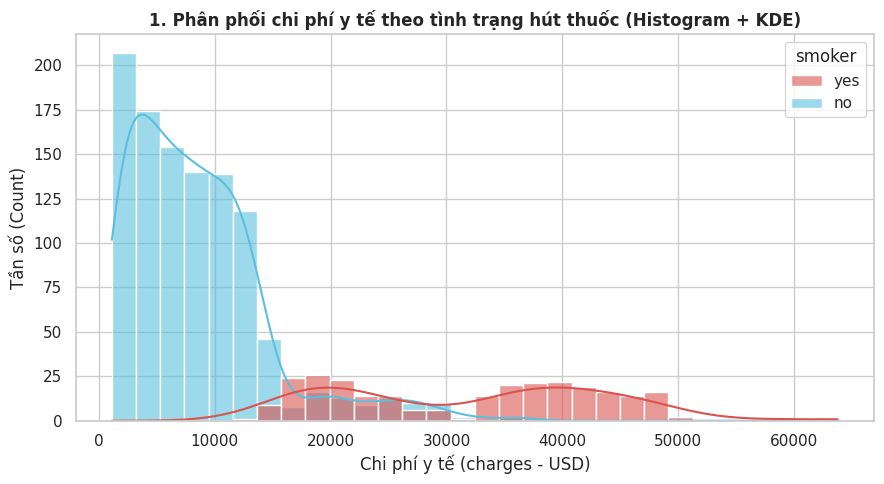

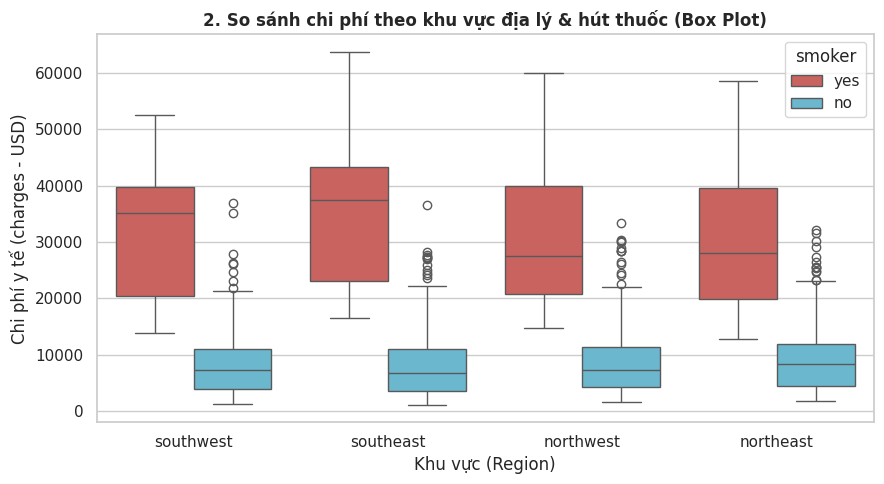

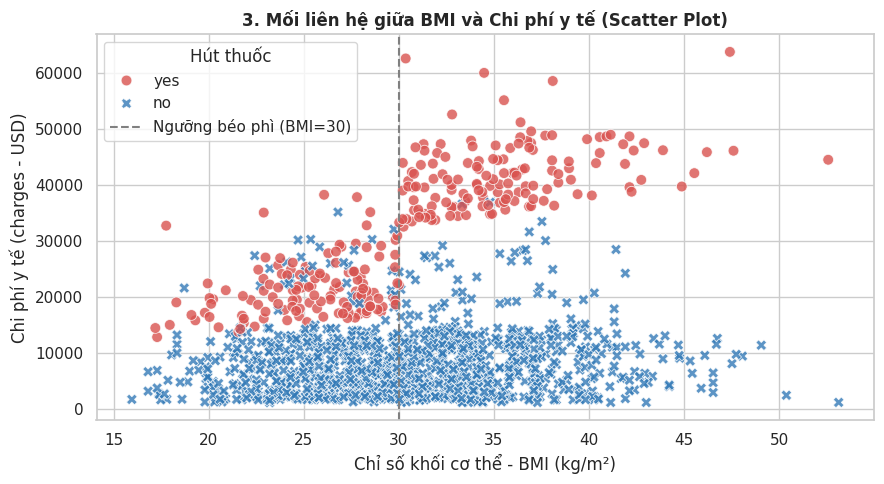

Đã lưu thành công 3 biểu đồ riêng biệt vào thư mục 'charts/'!


In [28]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu sạch
df = pd.read_csv('data/clean_data.csv')

# Cấu hình thẩm mỹ
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================================
# Biểu đồ 1: Histogram + KDE
# ==============================================================================
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='charges', hue='smoker', kde=True, bins=30, 
             palette={'yes': '#d9534f', 'no': '#5bc0de'}, alpha=0.6)
plt.title('1. Phân phối chi phí y tế theo tình trạng hút thuốc (Histogram + KDE)', fontsize=12, fontweight='bold')
plt.xlabel('Chi phí y tế (charges - USD)')
plt.ylabel('Tần số (Count)')
plt.tight_layout()
plt.savefig('charts/1_distribution_charges_smoker.png', dpi=300)
plt.show()
plt.close()

# ==============================================================================
# Biểu đồ 2: Box Plot
# ==============================================================================
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='region', y='charges', hue='smoker', 
            palette={'yes': '#d9534f', 'no': '#5bc0de'})
plt.title('2. So sánh chi phí theo khu vực địa lý & hút thuốc (Box Plot)', fontsize=12, fontweight='bold')
plt.xlabel('Khu vực (Region)')
plt.ylabel('Chi phí y tế (charges - USD)')
plt.tight_layout()
plt.savefig('charts/2_boxplot_charges_region_smoker.png', dpi=300)
plt.show()
plt.close()

# ==============================================================================
# Biểu đồ 3: Scatter Plot
# ==============================================================================
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', style='smoker', 
                palette={'yes': '#d9534f', 'no': '#337ab7'}, alpha=0.8, s=60)
plt.axvline(30, color='gray', linestyle='--', label='Ngưỡng béo phì (BMI=30)')
plt.title('3. Mối liên hệ giữa BMI và Chi phí y tế (Scatter Plot)', fontsize=12, fontweight='bold')
plt.xlabel('Chỉ số khối cơ thể - BMI (kg/m²)')
plt.ylabel('Chi phí y tế (charges - USD)')
plt.legend(title='Hút thuốc')
plt.tight_layout()
plt.savefig('charts/3_scatterplot_bmi_charges.png', dpi=300)
plt.show()
plt.close()

# ==============================================================================
print("Đã lưu thành công 3 biểu đồ riêng biệt vào thư mục 'charts/'!")

## 3. XỬ LÝ NGOẠI LAI
- **Phương pháp xác định:**
  1. **Quy tắc hàng rào khoảng tứ phân vị (IQR rule):** $[Q_1 - 1.5 \times IQR, Q_3 + 1.5 \times IQR]$ (thích hợp với biến lệch và không phụ thuộc giả định phân phối chuẩn).
  2. **Quy tắc điểm chuẩn hóa Z-score:** Điểm có $\vert{}Z\vert{} > 3$ (áp dụng cho biến xấp xỉ chuẩn như `bmi`).

In [24]:
# Viết hàm phát hiện outliers theo IQR
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lb = q1 - 1.5 * iqr
    ub = q3 + 1.5 * iqr
    outliers = series[(series < lb) | (series > ub)]
    return len(outliers), lb, ub

# Viết hàm phát hiện outliers theo Z-score (|Z| > 3)
def detect_outliers_zscore(series, threshold=3):
    z_scores = np.abs(stats.zscore(series))
    outliers = series[z_scores > threshold]
    return len(outliers)

def z_suitability(skew_val, is_discrete=False):
    if is_discrete:
        return "Không khuyến nghị (Biến đếm rời rạc, giá trị thực tế)"
    if abs(skew_val) < 0.5:
        return "Phù hợp (Phân phối xấp xỉ đối xứng / chuẩn)"
    elif abs(skew_val) < 1.0:
        return "Tương đối phù hợp (Lệch vừa)"
    else:
        return "Kém tin cậy (Lệch mạnh, che lấp ngoại lai)"

# 2. Khởi tạo danh sách và tổng hợp bảng so sánh
outlier_comparison = []

for col in num_cols:
    n_iqr, lb, ub = detect_outliers_iqr(df[col])
    n_z = detect_outliers_zscore(df[col], threshold=3)
    skew_val = df[col].skew()

    outlier_comparison.append({
        'Biến số': col,
        'Độ xiên (Skewness)': round(skew_val, 3),
        'Ngưỡng dưới (IQR)': round(lb, 2),
        'Ngưỡng trên (IQR)': round(ub, 2),
        'Số ngoại lai (IQR)': n_iqr,
        'Số ngoại lai (|Z| > 3)': n_z,
        'Đánh giá Z-score': z_suitability(skew_val, is_discrete=(col == 'children'))
    })

comparison_df = pd.DataFrame(outlier_comparison)
display(comparison_df)

# Phân tích bản chất các ngoại lai của charges
q1_c, q3_c = df['charges'].quantile(0.25), df['charges'].quantile(0.75)
ub_c = q3_c + 1.5 * (q3_c - q1_c)
charges_outliers = df[df['charges'] > ub_c]

print(f"\n--- PHÂN TÍCH {len(charges_outliers)} NGOẠI LAI CỦA BIẾN CHARGES (> {ub_c:.2f} USD) ---")
print("Phân bổ theo tình trạng hút thuốc:")
print(charges_outliers['smoker'].value_counts())
print(f"-> Tỷ lệ người hút thuốc trong nhóm ngoại lai: {(charges_outliers['smoker'] == 'yes').sum() / len(charges_outliers) * 100:.2f}%")

,Biến số,Độ xiên (Skewness),Ngưỡng dưới (IQR),Ngưỡng trên (IQR),Số ngoại lai (IQR),Số ngoại lai (|Z| > 3),Đánh giá Z-score
0,age,0.0550,-9.0000,87.0000,0,0,Phù hợp (Phân phối xấp xỉ đối xứng / chuẩn)
1,bmi,0.2840,13.6700,47.3200,9,4,Phù hợp (Phân phối xấp xỉ đối xứng / chuẩn)
2,children,0.9370,-3.0000,5.0000,0,18,"Không khuyến nghị (Biến đếm rời rạc, giá trị t..."
3,charges,1.5150,-13120.7200,34524.7800,139,7,"Kém tin cậy (Lệch mạnh, che lấp ngoại lai)"



--- PHÂN TÍCH 139 NGOẠI LAI CỦA BIẾN CHARGES (> 34524.78 USD) ---
Phân bổ theo tình trạng hút thuốc:
smoker
yes    136
no       3
Name: count, dtype: int64
-> Tỷ lệ người hút thuốc trong nhóm ngoại lai: 97.84%


#### 1. Đánh giá tính phù hợp giữa hai phương pháp (IQR vs Z-score)
* **Phương pháp Z-score ($\vert{}Z\vert{} > 3$):** 
  * Hoạt động tốt trên hai biến `age` (0 ngoại lai) và `bmi` (4 ngoại lai) do dữ liệu có phân phối đối xứng tiệm cận chuẩn ($\text{Skewness} \approx 0.055$ và $0.284$).
  * **Kém tin cậy trên biến `charges`:** Biến chi phí có độ lệch phải rất lớn ($\text{Skewness} = 1.515$), khiến các giá trị viện phí cực đại kéo độ lệch chuẩn $\sigma$ tăng vọt lên mức xấp xỉ $12.110$ USD. Hiện tượng này làm giãn ngưỡng trên của Z-score lên đến gần $50.000$ USD, dẫn đến **hiệu ứng che lấp ngoại lai (masking effect)** và chỉ phát hiện được 7 điểm.
  * **Không phù hợp trên biến `children`:** Vì đây là biến đếm rời rạc (từ 0 đến 5 con), Z-score gán cờ cho 18 trường hợp có 5 con là ngoại lai, dù đây là số liệu nhân khẩu học hoàn toàn hợp lệ.
* **Phương pháp IQR (Hàng rào tứ phân vị):** 
  * Mang tính **phi tham số (non-parametric)**, không bị ảnh hưởng bởi hình dạng phân phối hay các giá trị cực trị.
  * Phát hiện chính xác **9 điểm ngoại lai** ở biến `bmi` ($> 47.32\text{ kg/m}^2$) và **139 điểm ngoại lai** ở biến `charges` ($> 34.524,78$ USD), phản ánh trung thực mức độ phân tán của dữ liệu. Do đó, **IQR là phương pháp được chọn làm chuẩn nhận diện cho toàn bộ phân tích**.

### Đề xuất phương pháp xử lý ngoại lai:
1. **Đối với `bmi` (9 ngoại lai theo IQR):**
   - Giá trị BMI cao nhất là $53.13 \ kg/m^2$, hoàn toàn hợp lý về mặt sinh học lâm sàng (bệnh nhân béo phì độ III). Không phải lỗi nhập liệu. Do đó **giữ nguyên dữ liệu**.
2. **Đối với `charges` (139 ngoại lai theo IQR):**
   - Có đến **97.8% (136/139 ca)** ngoại lai thuộc nhóm có hút thuốc (`smoker = yes`). Đây là rủi ro y tế và chi phí điều trị thực tế, không phải nhiễu dữ liệu.
   - **Tuyệt đối không xóa bỏ (dropping)** hay **cắt nén phân vị chủ quan (Winsorization 99%)** vì sẽ làm sai lệch bản chất phân phối chi phí bảo hiểm.
   - **Đề xuất xử lý tối ưu:** Giữ nguyên dữ liệu trong `clean_data.csv` để làm thống kê và kiểm định; áp dụng phép biến đổi logarit $\ln(\text{charges})$ khi xây dựng mô hình Hồi quy tuyến tính đa biến ở Phần 5.

In [23]:
# ==============================================================================
# XỬ LÝ NGOẠI LAI VÀ CẬP NHẬT VÀO CLEAN_DATA.CSV
# ==============================================================================

# 1. Áp dụng phép biến đổi Log-transform để xử lý độ lệch và ngoại lai của charges
df['log_charges'] = np.log(df['charges'])

# 2. Cập nhật và lưu lại file clean_data.csv với cột dữ liệu mới
output_path = 'data/clean_data.csv'
df.to_csv(output_path, index=False)

print(f"-> ĐÃ CẬP NHẬT FILE SẠCH THÀNH CÔNG: {output_path}")
print(f"* Số lượng dòng (bảo toàn nguyên vẹn): {df.shape[0]}")
print(f"* Số lượng cột (đã thêm 'log_charges'): {df.shape[1]}")
display(df.head())

-> ĐÃ CẬP NHẬT FILE SẠCH THÀNH CÔNG: data/clean_data.csv
* Số lượng dòng (bảo toàn nguyên vẹn): 1337
* Số lượng cột (đã thêm 'log_charges'): 8


,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,female,27.9000,0,yes,southwest,16884.9240,9.7342
1,18,male,33.7700,1,no,southeast,1725.5523,7.4533
2,28,male,33.0000,3,no,southeast,4449.4620,8.4005
3,33,male,22.7050,0,no,northwest,21984.4706,9.9981
4,32,male,28.8800,0,no,northwest,3866.8552,8.2602


### 4. Nhận xét tổng quan về tập dữ liệu

Dựa trên kết quả khám phá dữ liệu (EDA), kiểm tra tính toàn vẹn và trực quan hóa, rút ra 5 đặc điểm nổi bật sau:

* **Chất lượng dữ liệu đạt chuẩn cao:** Bộ dữ liệu gồm **1.337 quan sát** và **7 biến số** sau khi loại bỏ 1 dòng trùng lặp. Dữ liệu không có giá trị khuyết thiếu (0 missing value), 100% biến phân loại và biến số đều nằm đúng miền giá trị logic kỳ vọng.
* **Cơ cấu nhân khẩu học phân bổ đồng đều:** 
  * Giới tính cân bằng tối ưu giữa Nam (50.5%) và Nữ (49.5%).
  * Địa bàn cư trú chia đều cho 4 khu vực (mỗi vùng xấp xỉ 24% – 27%).
  * Độ tuổi trải rộng từ 18 đến 64 tuổi (trung bình 39.2 tuổi), đại diện tốt cho độ tuổi lao động tham gia bảo hiểm.
* **Biến thể trạng (BMI) tiệm cận phân phối chuẩn:** Chỉ số BMI có phân phối hình chuông đối xứng quanh giá trị trung bình **30.66 kg/m²** (ngưỡng thừa cân/tiền béo phì theo chuẩn WHO). Có 9 trường hợp ngoại lai phía trên ($BMI > 47.32$) nhưng hoàn toàn phù hợp với thực tế y khoa.
* **Biến mục tiêu (charges) lệch phải mạnh:** Chi phí y tế có độ xiên dương lớn ($\text{Skewness} = 1.515$), giá trị trung bình ($13.279$ USD) chênh lệch đáng kể so với trung vị ($9.386$ USD). Toàn bộ 139 điểm ngoại lai thống kê ($> 34.525$ USD) đều là chi phí phát sinh thực tế với phân phối đuôi dài (fat-tail).
* **Hành vi hút thuốc là yếu tố chi phối rủi ro hàng đầu:**
  * Nhóm hút thuốc chỉ chiếm **20.5%** tổng mẫu nhưng chiếm đến **97.8% (136/139)** số ca viện phí ngoại lai.
  * Chi phí y tế trung bình của người hút thuốc vọt lên mức **~32.050 USD** (cao gấp 3.8 lần nhóm không hút thuốc, vốn chỉ ~8.441 USD).
  * Xuất hiện **hiệu ứng tương tác rõ rệt giữa BMI và hút thuốc:** Người hút thuốc kèm thể trạng béo phì ($BMI \ge 30$) có chi phí điều trị tăng vọt lên phân khúc cao nhất ($> 35.000$ USD).